In [1]:
# 事前準備
import pprint
from caret_analyze.plot import chain_latency
from caret_analyze import Application, Architecture, Lttng
from bokeh.plotting import output_notebook, figure, show
from caret_analyze.plot import Plot
from bokeh.io import export_png
from IPython.display import Image, display
import os

output_notebook()

# topicのpublisherを取得する
def get_publishers(app, topic_name):
    for pub in app.publishers:
        if pub.topic_name == topic_name:
            return pub
    return None

# topicのsubscriptionを取得する
def get_subscriptions(app, topic_name):
    for sub in app.subscriptions:
        if sub.topic_name == topic_name:
            return sub
    return None

Succeed to find record_cpp_impl. the C++ version will be used.


Loading BokehJS ...

In [2]:
# 設定ファイルの読み込み
# 通常時のコンフィグ
arch = Architecture('yaml', '../config/caret_arch_sample_node.yaml')

# CARETログ読み込み
# 最新ログの読み込み
import glob
log_name = os.getenv("CARET_LOG_NAME", "record_stress_non_rt")
latest_log_path = sorted(glob.glob("../../logs/" + log_name + "/*"))[-1] + "/caret/samplenode"
lttng = Lttng(latest_log_path)
# 実際のログへのパス例
# lttng = Lttng('../../logs/pattern1/20240902173918/caret/samplenode')

app = Application(arch, lttng)

5657 events found.


loading:   0%|          | 0/151 [00:00<?, ?it/s]

loading: 100%|██████████| 151/151 [00:00<00:00, 231822.81it/s]

loading:   0%|          | 0/5506 [00:00<?, ?it/s]

loading: 100%|██████████| 5506/5506 [00:00<00:00, 54866.84it/s]

filtered to 5657 events.


In [3]:

# 可視化したいパスを指定する
path = app.get_path("sample_node_path")

# パスレイテンシ(End-to-Endレイテンシ・ジッタ)を可視化する
plot = Plot.create_response_time_stacked_bar_plot(path)
plot.show()

In [4]:
# (上で指定したパスの)ノード処理と通信処理のフローを可視化する
plot = Plot.create_message_flow_plot(path, granularity='node', lstrip_s=1, rstrip_s=1)
plot.show()

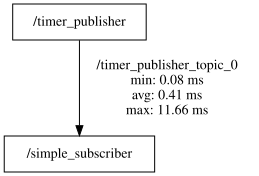

In [5]:
# (上で指定したパスの)パスレイテンシの内訳を可視化する
chain_latency(path, granularity='node', lstrip_s=1, rstrip_s=1)

In [6]:
# ドロップ率の計算
for comm in path.communications:
    df = comm.to_dataframe()
    cols = comm.column_names
    pub_col = cols[0]
    sub_col = cols[1]
    n_pub = df[pub_col].notna().sum()
    n_sub = df[sub_col].notna().sum()
    print(f'pub {pub_col}: count={n_pub} \nsub {sub_col}: count={n_sub}')
    drop_rate = (n_pub - n_sub) / n_pub if n_pub else 0.0
    print(f'{comm.topic_name}: drop_rate={drop_rate:.3%}')

pub /timer_publisher_topic_0/rclcpp_publish_timestamp: count=297 
sub /timer_publisher_topic_0/rcl_publish_timestamp: count=297
/timer_publisher_topic_0: drop_rate=0.000%


In [7]:
# コールバック関数の実行時刻(timestamp)と実行周期からのずれ(latency/ジッタ)を表示する
plot = Plot.create_latency_timeseries_plot(app.callbacks)
plot.show()
latency_df = plot.to_dataframe()
latency_df

/simple_subscriber/callback_0              /simple_subscriber/callback_1  \
    callback_start_timestamp [ns] latency [ms] callback_start_timestamp [ns]   
0             1790554215515948429     5.622691           1790554215521721249   
1             1790554215614401742     5.692509           1790554215607739791   
2             1790554215712976450     5.652073           1790554215707762823   
3             1790554215812911037     5.752714           1790554215807732659   
4             1790554215913008669     5.825175           1790554215907798213   
..                            ...          ...                           ...   
292           1790554244712918359     5.157153           1790554244707736561   
293           1790554244812812315     5.188675           1790554244807647940   
294           1790554244912847836     5.110591           1790554244907695048   
295           1790554245012874993     5.197417           1790554245007649785   
296           1790554245112713597     5.104551           1790554245107586359   

                   /timer_publisher/callback_0               
    latency [ms] callback_start_timestamp [ns] latency [ms]  
0       5.128258           1790554215506229080      9.67503  
1       6.547078           1790554215602250049     5.424178  
2       5.088774           1790554215702246022     5.422137  
3       5.073212           1790554215802250991     5.400909  
4       5.081991           1790554215902274951     5.422095  
..           ...                           ...          ...  
292     5.102051           1790554244702260665     5.419269  
293     5.071954           1790554244802307600     5.293461  
294     5.066293           1790554244902283781     5.369158  
295     5.148563           1790554245002229306     5.367835  
296     5.068174           1790554245102246610     5.301949  

[297 rows x 6 columns]

In [8]:
# コールバック関数の実行周期からのずれ(起動タイミングのジッタ)を可視化する
plot = Plot.create_period_timeseries_plot(app.callbacks)
plot.show()

In [9]:
# オーバーラン率の計算
# 仕様変更がありそうな箇所なので、プロットデータを使わず自前でデータ収集
# タイマーコールバック抽出
import numpy as np
timer_cbs = [cb for cb in app.callbacks if str(cb.callback_type)=='timer_callback']
print(f'{len(timer_cbs)}')
for cb in timer_cbs:
    df = cb.to_dataframe()
    start_col = cb.column_names[0]
    starts = df[start_col].dropna().astype('int64')
    intervals = starts.diff().dropna()
    n = len(intervals)
    if n == 0:
        print(f'{cb.callback_name}:データなし')
        continue

    #実行周期取得
    expected = cb.timer.period_ns
    # 実行周期からのジッタ
    jitter = intervals - expected
    overrun = (intervals > expected).sum()
    overrun_rate = overrun / n

    ideal = starts.iloc[0]+ np.arange(len(starts)) * expected
    abs_offset = (starts.values - ideal)

    print(f'callback: {cb.callback_name}----')
    print(f'指定周期      : {expected/1e6:.2f}ms')
    print(f'実測周期      : {intervals.mean()/1e6:.2f}ms (std{intervals.std()/1e6:.3f})')
    print(f'min/max      : {intervals.min()/1e6:.2f} / {intervals.max()/1e6:.2f}')
    print(f'最大遅延      : {jitter.max()/1e6:+.3f}')
    print(f'理想からのズレ : max {abs_offset.max()/1e6:+.3f} ms / min {abs_offset.max()/1e6:+.3f} ms')
    print(f'オーバーラン率 : {overrun_rate:.3%}')
    print("------\n")

2
callback: /simple_subscriber/callback_0----
指定周期      : 100.00ms
実測周期      : 99.99ms (std0.838)
min/max      : 95.31 / 105.59
最大遅延      : +5.589
理想からのズレ : max +0.976 ms / min +0.976 ms
オーバーラン率 : 49.324%
------

callback: /timer_publisher/callback_0----
指定周期      : 100.00ms
実測周期      : 99.99ms (std1.024)
min/max      : 94.49 / 105.52
最大遅延      : +5.519
理想からのズレ : max +1.559 ms / min +1.559 ms
オーバーラン率 : 48.649%
------



In [10]:
cb = app.callbacks # app.get_callback("/timer_driven_node/callback_1")

plot = Plot.create_latency_histogram_plot(cb)
plot.show()

In [11]:
plot = Plot.create_frequency_histogram_plot(cb)
plot.show()


In [12]:
plot = Plot.create_response_time_histogram_plot(path)
plot.show()

In [13]:
plot = Plot.create_period_histogram_plot(cb)
plot.show()